# **Distinguishing Children with autism specturm**



### *(Dataset -> Loading -> Pose Extraction -> Training -> Prediction)*
---
Hi, This is Md.Dilshad.The code here is for Educational use only. Not a diagnostic tool and its in the early stage of development and heavily copyrighted and as its been from the early dawn of civilization that science and social laws interected with each other to maintain the balance of society,the children footage on the dataset is strictly private and legal action will be taken by kollani special school mirpur 1216 authority if used by anyone rather than the authorized permitted persons like us only. This prototype is promising so it is intended to submit it as a project of knowledge engineering as we are passionate more about working on creative things rather than just build upon someone elses work and develop it further with more dataset and research videos for more practical and on flied usage. If anyone interested please mail the main author at mddillshadul98@gmail.com.

In [ ]:
!pip uninstall -y mediapipe numpy protobuf opencv-python tensorflow
!pip install numpy==1.24.4
!pip install mediapipe==0.10.21
!pip install protobuf==4.25.3
!pip install opencv-python==4.11.0.86
!pip install tensorflow==2.15.0


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: protobuf 5.29.6
Uninstalling protobuf-5.29.6:
  Successfully uninstalled protobuf-5.29.6
Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92
Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 71.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfull

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 8.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.8
    Uninstalling protobuf-4.25.8:
      Successfully uninstalled protobuf-4.25.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, which is not installed.
dopamine-rl 4.1.2 requires opencv-python>=3.4.8.29, which is not installed.
dopamine-rl 4.1.2 requires tensorflow>=2.2.0, which is not installed.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.3 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.3 which is incompatible.
google-api-core 2.30.0 requires protobuf<7.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
grpcio-status 1.71.2 requires prot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 12.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires tensorflow>=2.2.0, which is not installed.
ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1)
ERROR: No matching distribution found for tensorflow==2.15.0


In [ ]:
!pip install mediapipe==0.10.21 tensorflow==2.19.0 opencv-python==4.11.0.86 --quiet
!pip install numpy==1.24.4 protobuf==5.3.0 ml-dtypes==0.5.1 --quiet



print("Dependencies installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
Dependencies installed!


In [ ]:
import numpy as np
import mediapipe as mp
import cv2
import tensorflow as tf

print("NumPy:", np.__version__)
print("MediaPipe:", mp.__version__)
print("OpenCV:", cv2.__version__)
print("TensorFlow:", tf.__version__)

/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.7.1, so it will not be used.
  warnings.warn(


NumPy: 1.26.4
MediaPipe: 0.10.21
OpenCV: 4.11.0
TensorFlow: 2.19.0


In [ ]:
#Imports
import os, glob, random, tqdm
import numpy as np
import cv2
import mediapipe as mp
from collections import Counter

# ML
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, utils

mp_pose = mp.solutions.pose


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
dataset_root = '/content/drive/MyDrive/autism_children_research_videos/'


Mounted at /content/drive


In [ ]:
labels = [
  "finger_cliping",
  "hand_flapping",
  "head_touching",
  "spining",
  "tilting",
  "toe_walking"
]
print("Using labels:", labels)


Using labels: ['finger_cliping', 'hand_flapping', 'head_touching', 'spining', 'tilting', 'toe_walking']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Pose extraction function (resample to fixed length)
def extract_pose_sequence_from_video(video_path, num_frames_out=30, resize_width=640):
    cap = cv2.VideoCapture(video_path)
    frames = []
    success, frame = cap.read()
    while success:
        if resize_width:
            h,w = frame.shape[:2]
            new_h = int(h * (resize_width / float(w)))
            frame = cv2.resize(frame, (resize_width, new_h))
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        success, frame = cap.read()
    cap.release()
    if len(frames) == 0:
        return None

    pose = mp_pose.Pose(static_image_mode=False, model_complexity=1,
                        min_detection_confidence=0.4, min_tracking_confidence=0.4)
    seq = []
    for img in frames:
        results = pose.process(img)
        if results.pose_landmarks:
            row = []
            for lm in results.pose_landmarks.landmark:
                row.extend([lm.x, lm.y, lm.visibility])
        else:
            n_landmarks = 33
            row = [0.0] * (n_landmarks * 3)
        seq.append(row)
    pose.close()

    seq = np.array(seq)  # shape (T, dims)
    T = seq.shape[0]
    if T == num_frames_out:
        return seq
    elif T < num_frames_out:
        pad_cnt = num_frames_out - T
        last = seq[-1]
        seq = np.vstack([seq, np.tile(last, (pad_cnt,1))])
        return seq
    else:
        idx = np.linspace(0, T-1, num_frames_out).astype(int)
        return seq[idx]


In [ ]:
# Augmentation
def temporal_crop(seq, out_len):
    T = seq.shape[0]
    if T <= out_len:
        pad = np.tile(seq[-1], (out_len-T,1))
        return np.vstack([seq, pad])
    start = np.random.randint(0, T-out_len+1)
    return seq[start:start+out_len]

def time_warp(seq, scale=0.9):
    T = seq.shape[0]
    new_T = max(5, int(round(T * scale)))
    idx = np.linspace(0, T-1, new_T).astype(int)
    seq2 = seq[idx]
    idx2 = np.linspace(0, new_T-1, T).astype(int)
    return seq2[idx2]

def horiz_flip(seq):
    seq2 = np.copy(seq)
    # flip x coordinates (every 3 dims: x, y, vis)
    seq2[:, ::3] = 1.0 - seq2[:, ::3]
    return seq2


In [ ]:
# dataset: extract sequences from all clips
num_frames = 30  # fixed sequence length (tweakable)
X_seq = []
y = []
paths = []

for lbl_idx, lbl in enumerate(labels):
    folder = os.path.join(dataset_root, lbl)
    if not os.path.isdir(folder):
        print("Warning: missing folder:", folder)
        continue
    files = sorted(glob.glob(os.path.join(folder, '*.mp4')) + glob.glob(os.path.join(folder, '*.avi')))
    print(f"{lbl}: {len(files)} files")
    for p in tqdm.tqdm(files):
        seq = extract_pose_sequence_from_video(p, num_frames_out=num_frames)
        if seq is None:
            print("skipped (no frames):", p)
            continue
        X_seq.append(seq)
        y.append(lbl_idx)
        paths.append(p)

X_seq = np.array(X_seq)   # (N, num_frames, dims)
y = np.array(y)
print("Raw dataset built:", X_seq.shape, "labels:", y.shape)


finger_cliping: 45 files


100%|██████████| 45/45 [03:07<00:00,  4.16s/it]


hand_flapping: 54 files


100%|██████████| 54/54 [02:59<00:00,  3.33s/it]


head_touching: 4 files


...

tilting: 14 files


100%|██████████| 14/14 [01:02<00:00,  4.49s/it]


toe_walking: 7 files


100%|██████████| 7/7 [00:22<00:00,  3.17s/it]

Raw dataset built: (129, 30, 99) labels: (129,)


In [ ]:
#Augment tiny classes toward target_count (e.g., 50)
def augment_dataset(X_seq, y, paths, target_per_class=50):
    X_out = list(X_seq)
    y_out = list(y)
    p_out = list(paths)
    counts = Counter(y)
    for cls, cnt in counts.items():
        need = max(0, target_per_class - cnt)
        if need == 0: continue
        idxs = [i for i,v in enumerate(y) if v==cls]
        for _ in range(need):
            src = random.choice(idxs)
            seq = X_seq[src].copy()
            if random.random() < 0.6:
                seq = time_warp(seq, scale=random.uniform(0.85,1.15))
            if random.random() < 0.6:
                seq = temporal_crop(seq, num_frames)
            if random.random() < 0.5:
                seq = horiz_flip(seq)
            X_out.append(seq)
            y_out.append(cls)
            p_out.append(paths[src] + "_aug")
    return np.array(X_out), np.array(y_out), p_out

X_seq, y, paths = augment_dataset(X_seq, y, paths, target_per_class=50)
print("After augmentation:", X_seq.shape, y.shape)
for i,c in sorted(Counter(y).items()):
    print(labels[i], ":", c)


After augmentation: (304, 30, 99) (304,)
finger_cliping : 50
hand_flapping : 54
head_touching : 50
spining : 50
tilting : 50
toe_walking : 50


Feature matrix: (304, 495)

===== Running Multi-Model Comparison with K-Fold =====
RandomForest CV Accuracy: 0.8522
SVM CV Accuracy: 0.4868


lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the doc

LogisticRegression CV Accuracy: 0.7993
KNN CV Accuracy: 0.6777
GradientBoosting CV Accuracy: 0.8587

Model Comparison Table:
                    Accuracy
GradientBoosting    0.858689
RandomForest        0.852186
LogisticRegression  0.799344
KNN                 0.677650
SVM                 0.486776

===== Soft Voting Ensemble =====


lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the doc

Soft Voting Accuracy: 0.8026775956284153

===== Hard Voting Ensemble =====


lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the doc

Hard Voting Accuracy: 0.8620218579234973


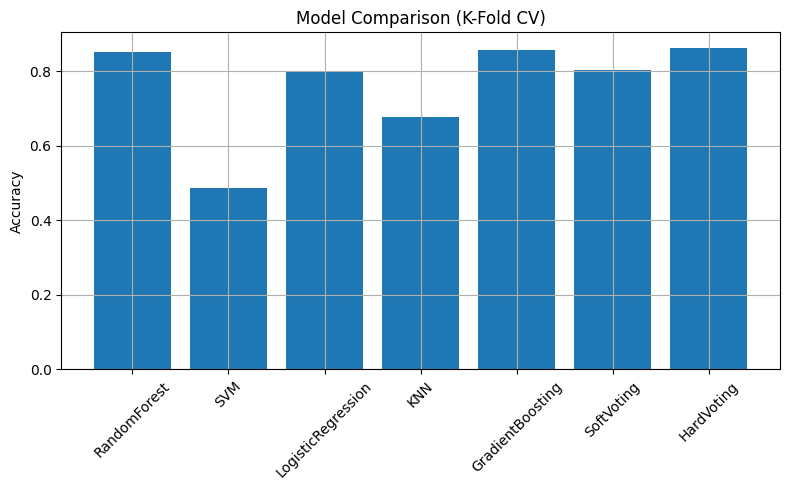


===== Final Model Accuracy Summary =====
RandomForest: 0.8522
SVM: 0.4868
LogisticRegression: 0.7993
KNN: 0.6777
GradientBoosting: 0.8587
SoftVoting: 0.8027
HardVoting: 0.8620


In [ ]:
#RandomForest baseline (feature-based) (cross validated)
def seq_to_features(seq):
    f_mean = seq.mean(axis=0)
    f_std = seq.std(axis=0)
    f_min = seq.min(axis=0)
    f_max = seq.max(axis=0)
    f_energy = np.sum(seq**2, axis=0)
    return np.concatenate([f_mean, f_std, f_min, f_max, f_energy])

X_feats = np.array([seq_to_features(s) for s in X_seq])
print("Feature matrix:", X_feats.shape)

# ============================================================
# MULTIPLE MODELS + K-FOLD VALIDATION + ENSEMBLE METHODS
# ============================================================

print("\n===== Running Multi-Model Comparison with K-Fold =====")

# 5-fold stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define models
models_dict = {
    "RandomForest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "SVM": SVC(probability=True, kernel='rbf'),
    "LogisticRegression": LogisticRegression(max_iter=3000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,   # ↓ smaller → less overfit
        max_depth=2,          # ↓ shallower trees
        subsample=0.8         # stochastic boosting
    )
}

results = {}

# Run cross validation
for name, model in models_dict.items():
    scores = cross_val_score(model, X_feats, y, cv=skf, scoring='accuracy')
    results[name] = scores.mean()
    print(f"{name} CV Accuracy: {scores.mean():.4f}")

# Convert results to dataframe
import pandas as pd
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
print("\nModel Comparison Table:")
print(results_df.sort_values("Accuracy", ascending=False))

# ------------------------------------------------------------
# SOFT VOTING ENSEMBLE
# ------------------------------------------------------------
print("\n===== Soft Voting Ensemble =====")

soft_vote = VotingClassifier(
    estimators=[
        ('rf', models_dict["RandomForest"]),
        ('svm', models_dict["SVM"]),
        ('lr', models_dict["LogisticRegression"])
    ],
    voting='soft'
)

soft_scores = cross_val_score(soft_vote, X_feats, y, cv=skf, scoring='accuracy')
results["SoftVoting"] = soft_scores.mean()
print("Soft Voting Accuracy:", soft_scores.mean())

# ------------------------------------------------------------
# HARD VOTING (MAX VOTING)
# ------------------------------------------------------------
print("\n===== Hard Voting Ensemble =====")

hard_vote = VotingClassifier(
    estimators=[
        ('rf', models_dict["RandomForest"]),
        ('lr', models_dict["LogisticRegression"]),
        ('gb', models_dict["GradientBoosting"])
    ],
    voting='hard'
)

hard_scores = cross_val_score(hard_vote, X_feats, y, cv=skf, scoring='accuracy')
results["HardVoting"] = hard_scores.mean()
print("Hard Voting Accuracy:", hard_scores.mean())

# ------------------------------------------------------------
# PLOT MODEL COMPARISON
# ------------------------------------------------------------
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Comparison (K-Fold CV)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n===== Final Model Accuracy Summary =====")
for k,v in results.items():
    print(f"{k}: {v:.4f}")




RF Accuracy: 0.8152173913043478
                precision    recall  f1-score   support

finger_cliping       0.70      0.47      0.56        15
 hand_flapping       0.60      0.53      0.56        17
 head_touching       0.94      1.00      0.97        15
       spining       0.88      1.00      0.94        15
       tilting       0.78      0.93      0.85        15
   toe_walking       0.94      1.00      0.97        15

      accuracy                           0.82        92
     macro avg       0.81      0.82      0.81        92
  weighted avg       0.80      0.82      0.80        92



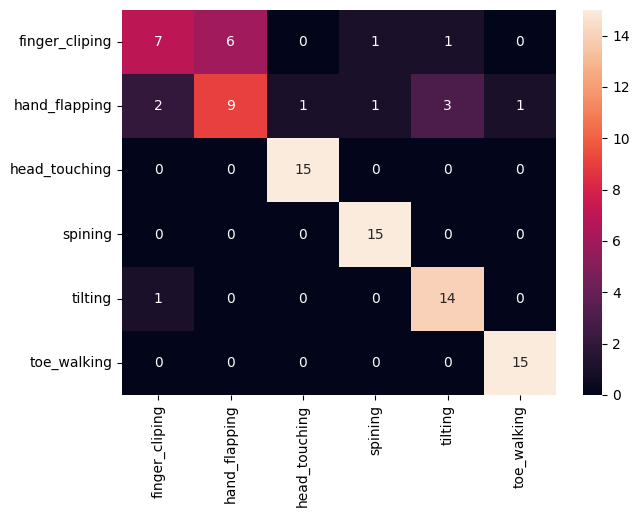

In [ ]:
# train/test split
X_tr, X_te, y_tr, y_te = train_test_split(X_feats, y, test_size=0.3, random_state=42, stratify=y)
clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
clf.fit(X_tr, y_tr)
y_pred = clf.predict(X_te)
print("RF Accuracy:", accuracy_score(y_te, y_pred))
print(classification_report(y_te, y_pred, target_names=labels))
cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(7,5)); sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels); plt.show()



SVM Accuracy: 0.41304347826086957
                precision    recall  f1-score   support

finger_cliping       0.20      0.07      0.10        15
 hand_flapping       0.24      0.35      0.29        17
 head_touching       0.33      0.33      0.33        15
       spining       0.50      0.53      0.52        15
       tilting       0.54      0.87      0.67        15
   toe_walking       0.71      0.33      0.45        15

      accuracy                           0.41        92
     macro avg       0.42      0.41      0.39        92
  weighted avg       0.42      0.41      0.39        92



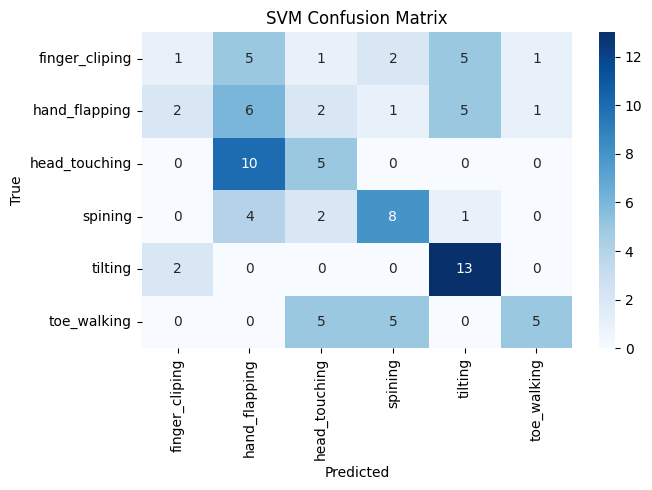

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression Accuracy: 0.7717391304347826
                precision    recall  f1-score   support

finger_cliping       0.56      0.33      0.42        15
 hand_flapping       0.56      0.59      0.57        17
 head_touching       0.88      1.00      0.94        15
       spining       0.79      1.00      0.88        15
       tilting       0.85      0.73      0.79        15
   toe_walking       0.94      1.00      0.97        15

      accuracy                           0.77        92
     macro avg       0.76      0.78      0.76        92
  weighted avg       0.76      0.77      0.76        92



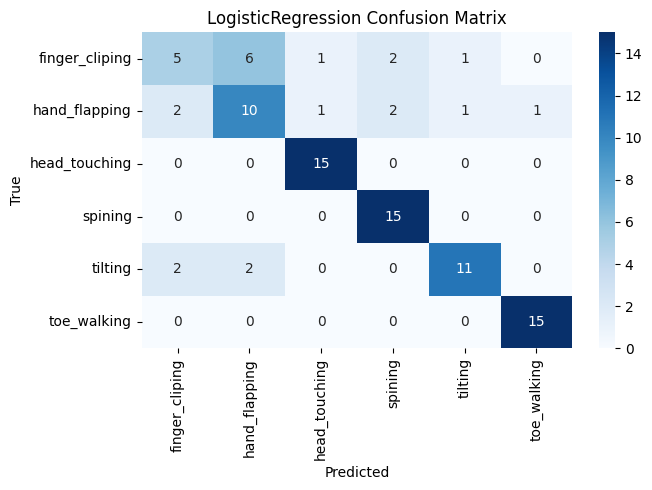


KNN Accuracy: 0.6304347826086957
                precision    recall  f1-score   support

finger_cliping       0.40      0.27      0.32        15
 hand_flapping       0.50      0.12      0.19        17
 head_touching       0.79      1.00      0.88        15
       spining       0.56      1.00      0.71        15
       tilting       0.67      0.67      0.67        15
   toe_walking       0.71      0.80      0.75        15

      accuracy                           0.63        92
     macro avg       0.60      0.64      0.59        92
  weighted avg       0.60      0.63      0.58        92



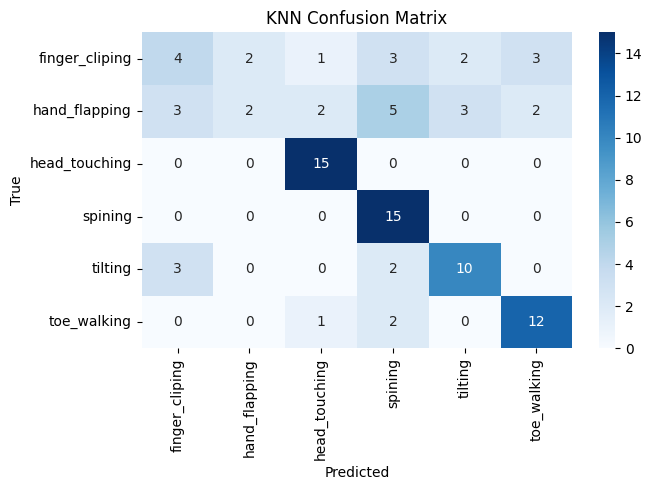


GradientBoosting Accuracy: 0.8043478260869565
                precision    recall  f1-score   support

finger_cliping       0.55      0.40      0.46        15
 hand_flapping       0.64      0.53      0.58        17
 head_touching       0.83      1.00      0.91        15
       spining       1.00      1.00      1.00        15
       tilting       0.78      0.93      0.85        15
   toe_walking       0.94      1.00      0.97        15

      accuracy                           0.80        92
     macro avg       0.79      0.81      0.79        92
  weighted avg       0.79      0.80      0.79        92



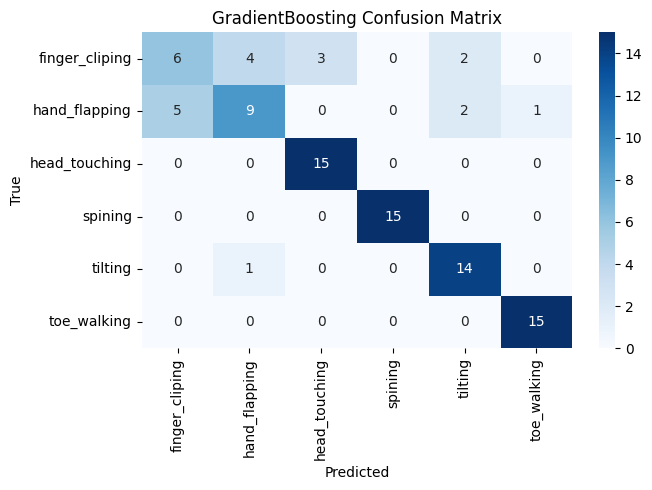

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



SoftVoting Accuracy: 0.7717391304347826
                precision    recall  f1-score   support

finger_cliping       0.56      0.33      0.42        15
 hand_flapping       0.56      0.59      0.57        17
 head_touching       0.88      1.00      0.94        15
       spining       0.75      1.00      0.86        15
       tilting       0.85      0.73      0.79        15
   toe_walking       1.00      1.00      1.00        15

      accuracy                           0.77        92
     macro avg       0.76      0.78      0.76        92
  weighted avg       0.76      0.77      0.76        92



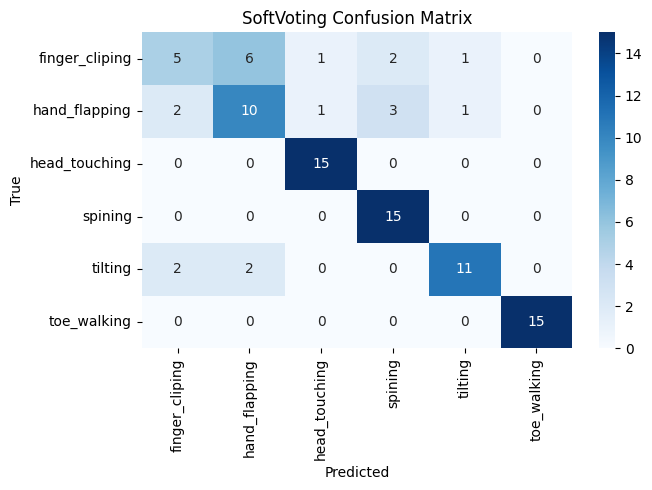

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



HardVoting Accuracy: 0.8152173913043478
                precision    recall  f1-score   support

finger_cliping       0.55      0.40      0.46        15
 hand_flapping       0.58      0.65      0.61        17
 head_touching       0.88      1.00      0.94        15
       spining       1.00      1.00      1.00        15
       tilting       0.87      0.87      0.87        15
   toe_walking       1.00      1.00      1.00        15

      accuracy                           0.82        92
     macro avg       0.81      0.82      0.81        92
  weighted avg       0.81      0.82      0.81        92



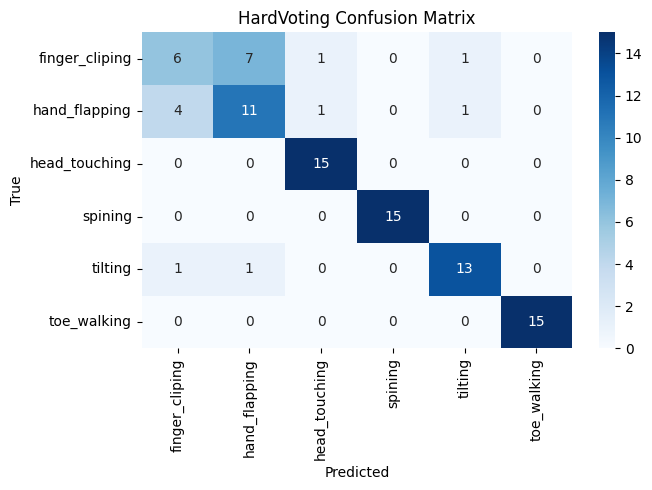

In [ ]:
final_models = {
    "SVM": models_dict["SVM"],
    "LogisticRegression": models_dict["LogisticRegression"],
    "KNN": models_dict["KNN"],
    "GradientBoosting": models_dict["GradientBoosting"],
    "SoftVoting": soft_vote,
    "HardVoting": hard_vote
}

for name, model in final_models.items():
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    print(f"\n{name} Accuracy:", accuracy_score(y_te, y_pred))
    print(classification_report(y_te, y_pred, target_names=labels))

    cm = confusion_matrix(y_te, y_pred)

    plt.figure(figsize=(7,5))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=labels, yticklabels=labels,
                cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


===== SVM =====
SVM Accuracy: 0.41304347826086957
                precision    recall  f1-score   support

finger_cliping       0.20      0.07      0.10        15
 hand_flapping       0.24      0.35      0.29        17
 head_touching       0.33      0.33      0.33        15
       spining       0.50      0.53      0.52        15
       tilting       0.54      0.87      0.67        15
   toe_walking       0.71      0.33      0.45        15

      accuracy                           0.41        92
     macro avg       0.42      0.41      0.39        92
  weighted avg       0.42      0.41      0.39        92



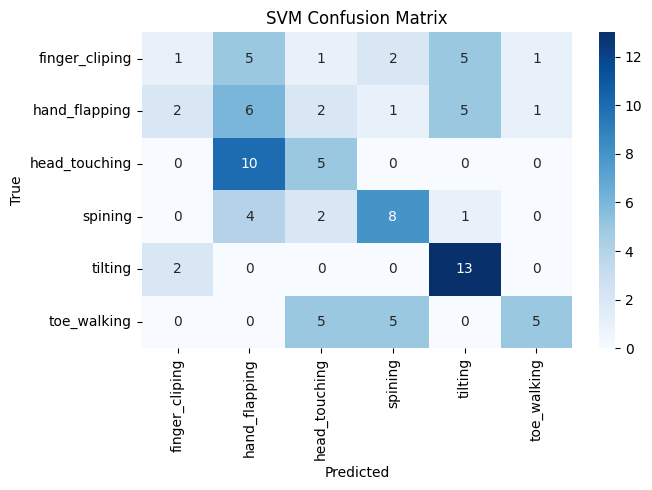


===== LogisticRegression =====


lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


LogisticRegression Accuracy: 0.7717391304347826
                precision    recall  f1-score   support

finger_cliping       0.56      0.33      0.42        15
 hand_flapping       0.56      0.59      0.57        17
 head_touching       0.88      1.00      0.94        15
       spining       0.79      1.00      0.88        15
       tilting       0.85      0.73      0.79        15
   toe_walking       0.94      1.00      0.97        15

      accuracy                           0.77        92
     macro avg       0.76      0.78      0.76        92
  weighted avg       0.76      0.77      0.76        92



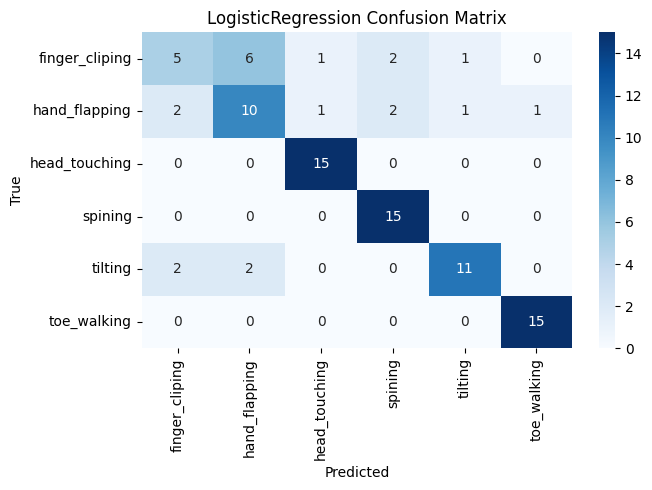


===== KNN =====
KNN Accuracy: 0.6304347826086957
                precision    recall  f1-score   support

finger_cliping       0.40      0.27      0.32        15
 hand_flapping       0.50      0.12      0.19        17
 head_touching       0.79      1.00      0.88        15
       spining       0.56      1.00      0.71        15
       tilting       0.67      0.67      0.67        15
   toe_walking       0.71      0.80      0.75        15

      accuracy                           0.63        92
     macro avg       0.60      0.64      0.59        92
  weighted avg       0.60      0.63      0.58        92



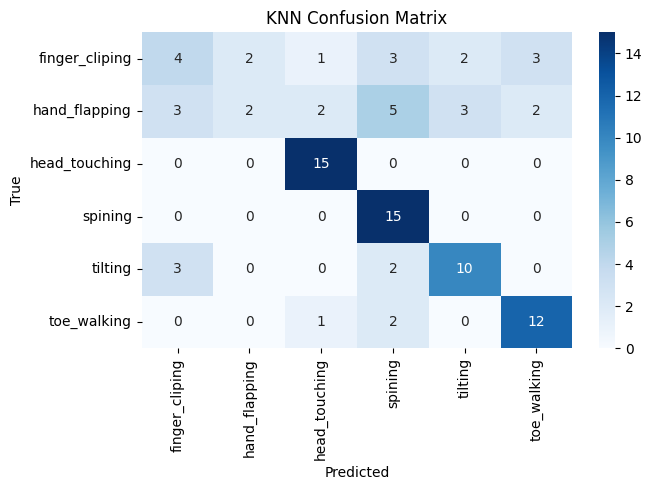


===== GradientBoosting =====
GradientBoosting Accuracy: 0.8152173913043478
                precision    recall  f1-score   support

finger_cliping       0.50      0.40      0.44        15
 hand_flapping       0.71      0.59      0.65        17
 head_touching       0.83      1.00      0.91        15
       spining       0.94      1.00      0.97        15
       tilting       0.82      0.93      0.88        15
   toe_walking       1.00      1.00      1.00        15

      accuracy                           0.82        92
     macro avg       0.80      0.82      0.81        92
  weighted avg       0.80      0.82      0.80        92



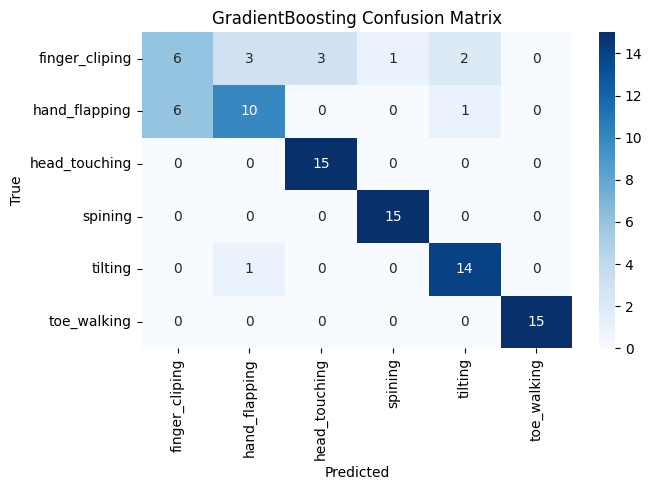


===== SoftVoting =====


lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


SoftVoting Accuracy: 0.7717391304347826
                precision    recall  f1-score   support

finger_cliping       0.56      0.33      0.42        15
 hand_flapping       0.56      0.59      0.57        17
 head_touching       0.88      1.00      0.94        15
       spining       0.75      1.00      0.86        15
       tilting       0.85      0.73      0.79        15
   toe_walking       1.00      1.00      1.00        15

      accuracy                           0.77        92
     macro avg       0.76      0.78      0.76        92
  weighted avg       0.76      0.77      0.76        92



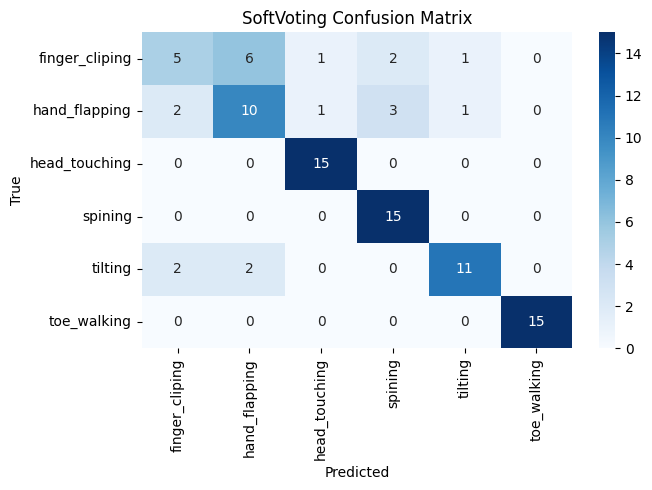


===== HardVoting =====


lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


HardVoting Accuracy: 0.8369565217391305
                precision    recall  f1-score   support

finger_cliping       0.67      0.53      0.59        15
 hand_flapping       0.65      0.65      0.65        17
 head_touching       0.88      1.00      0.94        15
       spining       1.00      1.00      1.00        15
       tilting       0.81      0.87      0.84        15
   toe_walking       1.00      1.00      1.00        15

      accuracy                           0.84        92
     macro avg       0.83      0.84      0.84        92
  weighted avg       0.83      0.84      0.83        92



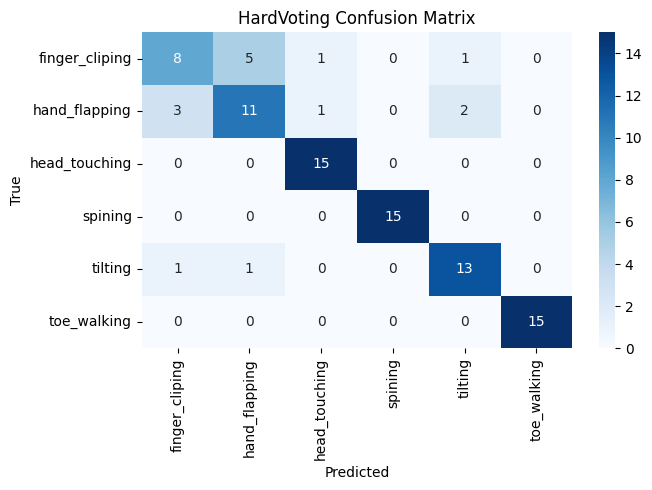

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in final_models.items():
    print(f"\n===== {name} =====")

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    print(f"{name} Accuracy:", accuracy_score(y_te, y_pred))
    print(classification_report(y_te, y_pred, target_names=labels))

    cm = confusion_matrix(y_te, y_pred)

    plt.figure(figsize=(7,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels
    )
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

In [ ]:
#Preparing sequence data for LSTM (scale and split)
# Flatten + scaler on train portion then reshape back
indices = np.arange(len(X_seq))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
scaler.fit(X_seq.reshape((X_seq.shape[0], -1))[train_idx])
X_seq_scaled = scaler.transform(X_seq.reshape((X_seq.shape[0], -1))).reshape(X_seq.shape)

X_train_seq = X_seq_scaled[train_idx]
X_test_seq = X_seq_scaled[test_idx]
y_train_seq = y[train_idx]
y_test_seq = y[test_idx]

y_train_oh = utils.to_categorical(y_train_seq, num_classes=len(labels))
y_test_oh = utils.to_categorical(y_test_seq, num_classes=len(labels))
print("Train seq shape:", X_train_seq.shape, "Test seq shape:", X_test_seq.shape)


Train seq shape: (243, 30, 99) Test seq shape: (61, 30, 99)


In [ ]:
#Build & train Bi-LSTM small
tf.keras.backend.clear_session()
model = models.Sequential([
    layers.Input(shape=X_train_seq.shape[1:]),  # (num_frames, dims)
    layers.Masking(mask_value=0.0),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.Bidirectional(layers.LSTM(32)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(len(labels), activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# class weights
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.unique(y_train_seq), y=y_train_seq)
class_weight = {i: cw[i] for i in range(len(cw))}
print("Class weights:", class_weight)

es = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
history = model.fit(X_train_seq, y_train_oh, validation_split=0.15, epochs=80, batch_size=8,
                    class_weight=class_weight, callbacks=[es])


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 30, 99)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        83,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,734 (506.77 KB)

 Trainable params: 129,734 (506.77 KB)

 Non-trainable params: 0 (0.00 B)

Class weights: {0: 1.0125, 1: 0.9418604651162791, 2: 1.0125, 3: 1.0125, 4: 1.0125, 5: 1.0125}
Epoch 1/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.2534 - loss: 1.7754 - val_accuracy: 0.4324 - val_loss: 1.4484
Epoch 2/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6483 - loss: 1.3333 - val_accuracy: 0.6486 - val_loss: 1.1531
Epoch 3/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7421 - loss: 0.9768 - val_accuracy: 0.7027 - val_loss: 0.9706
Epoch 4/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7765 - loss: 0.6618 - val_accuracy: 0.7027 - val_loss: 0.7805
Epoch 5/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8975 - loss: 0.4511 - val_accuracy: 0.6757 - val_loss: 0.6471
Epoch 6/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9085 - loss: 0.3667 - val_accuracy: 0.7297 - val_loss: 0.6491
Epoch 7/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9008 - loss: 0.3014 - val_accuracy: 0.7568 - val_loss: 0.6581
Epoch 8/80
26/26 

LSTM test accuracy: 0.7213114500045776
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step
                precision    recall  f1-score   support

finger_cliping       0.43      0.30      0.35        10
 hand_flapping       0.67      0.55      0.60        11
 head_touching       0.91      1.00      0.95        10
       spining       0.77      1.00      0.87        10
       tilting       0.67      0.60      0.63        10
   toe_walking       0.75      0.90      0.82        10

      accuracy                           0.72        61
     macro avg       0.70      0.72      0.70        61
  weighted avg       0.70      0.72      0.70        61



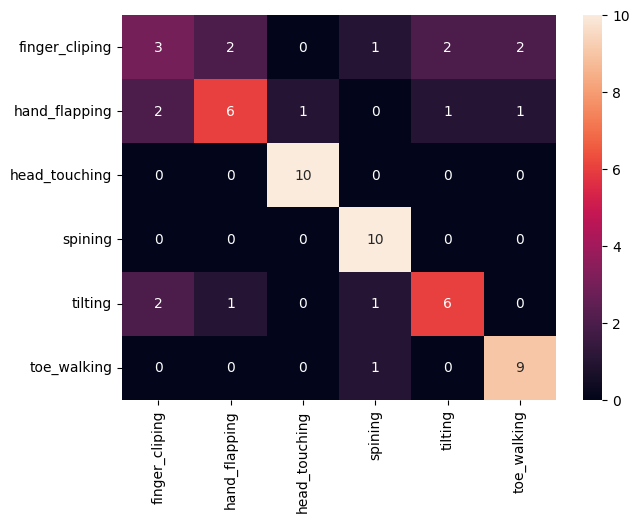

In [ ]:
# Evaluate LSTM model
loss, lstm_accuracy = model.evaluate(X_test_seq, y_test_oh, verbose=0)
print("LSTM test accuracy:", lstm_accuracy)

y_pred_probs = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_probs, axis=1)
print(classification_report(y_test_seq, y_pred, target_names=labels))
cm = confusion_matrix(y_test_seq, y_pred)
plt.figure(figsize=(7,5)); sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels); plt.show()


In [ ]:
#Single clip prediction helper (print % per class)
def predict_single_clip(model, clip_path, num_frames=num_frames):
    seq = extract_pose_sequence_from_video(clip_path, num_frames_out=num_frames)
    if seq is None:
        print("No frames or bad clip:", clip_path); return
    seq_scaled = scaler.transform(seq.reshape(1,-1)).reshape(1, seq.shape[0], seq.shape[1])
    probs = model.predict(seq_scaled)[0]
    for i,p in enumerate(probs):
        print(f"{labels[i]}: {p*100:.1f}%")
    print("Overall (max class prob):", probs.max()*100, "%")


# predict_single_clip(model, '/content/drive/MyDrive/asd_dataset/hand_flapping/hand_flapping_001.mp4')


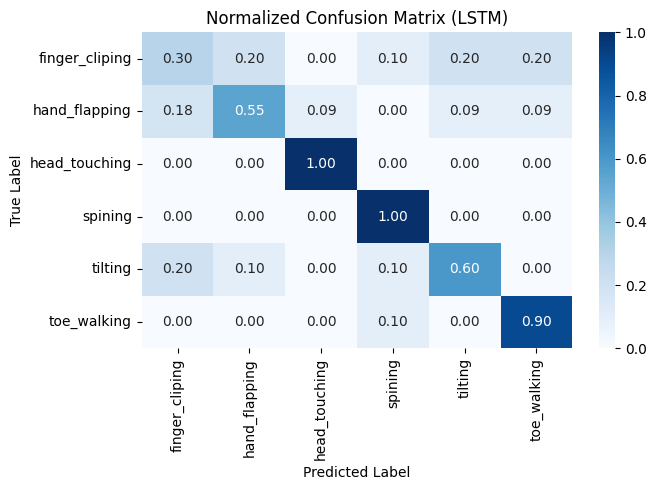

In [ ]:
# --- Normalized Confusion Matrix (LSTM)

cm = confusion_matrix(y_test_seq, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Blues"
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix (LSTM)")
plt.tight_layout()
plt.show()


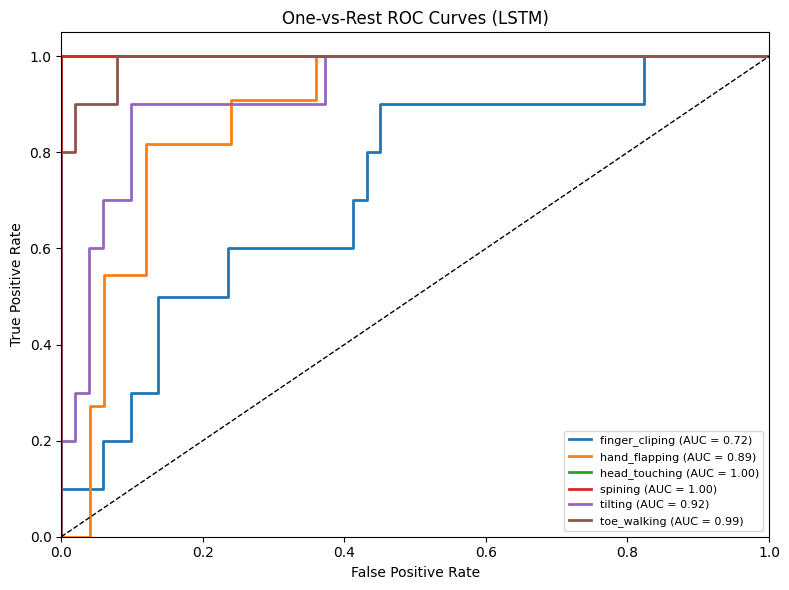

Per-class AUC scores:
finger_cliping: 0.722
hand_flapping: 0.885
head_touching: 1.000
spining: 1.000
tilting: 0.924
toe_walking: 0.990
Macro-average AUC: 0.9201247771836006


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels for One-vs-Rest ROC
y_test_bin = label_binarize(y_test_seq, classes=range(len(labels)))

plt.figure(figsize=(8, 6))

auc_scores = {}

for i, label in enumerate(labels):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores[label] = roc_auc
    plt.plot(fpr, tpr, lw=2, label=f"{label} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves (LSTM)")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

# Print AUC scores clearly
print("Per-class AUC scores:")
for k, v in auc_scores.items():
    print(f"{k}: {v:.3f}")

print("Macro-average AUC:", np.mean(list(auc_scores.values())))


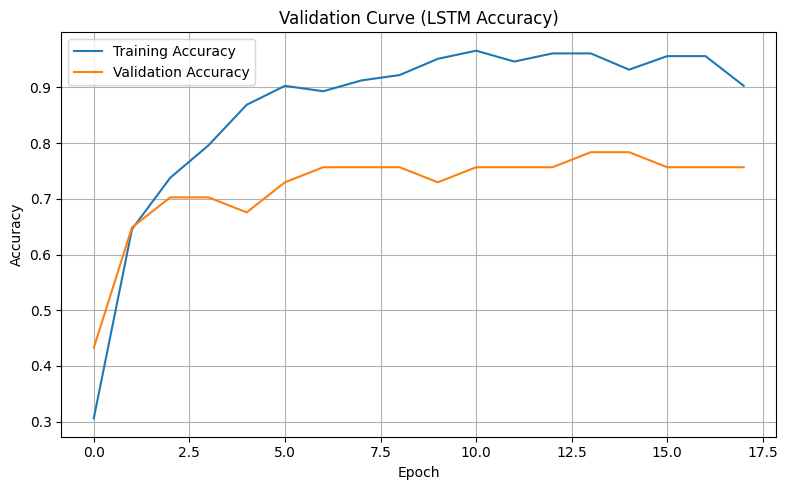

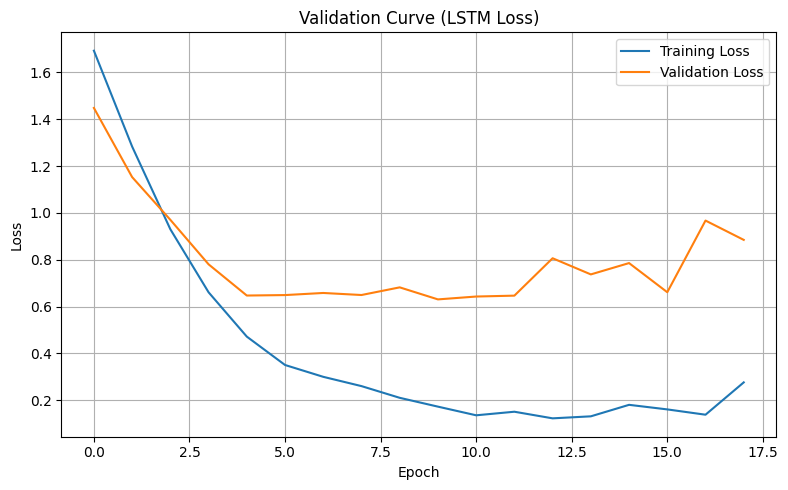

In [ ]:
# Validation Curves from Training History

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Curve (LSTM Accuracy)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Curve (LSTM Loss)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


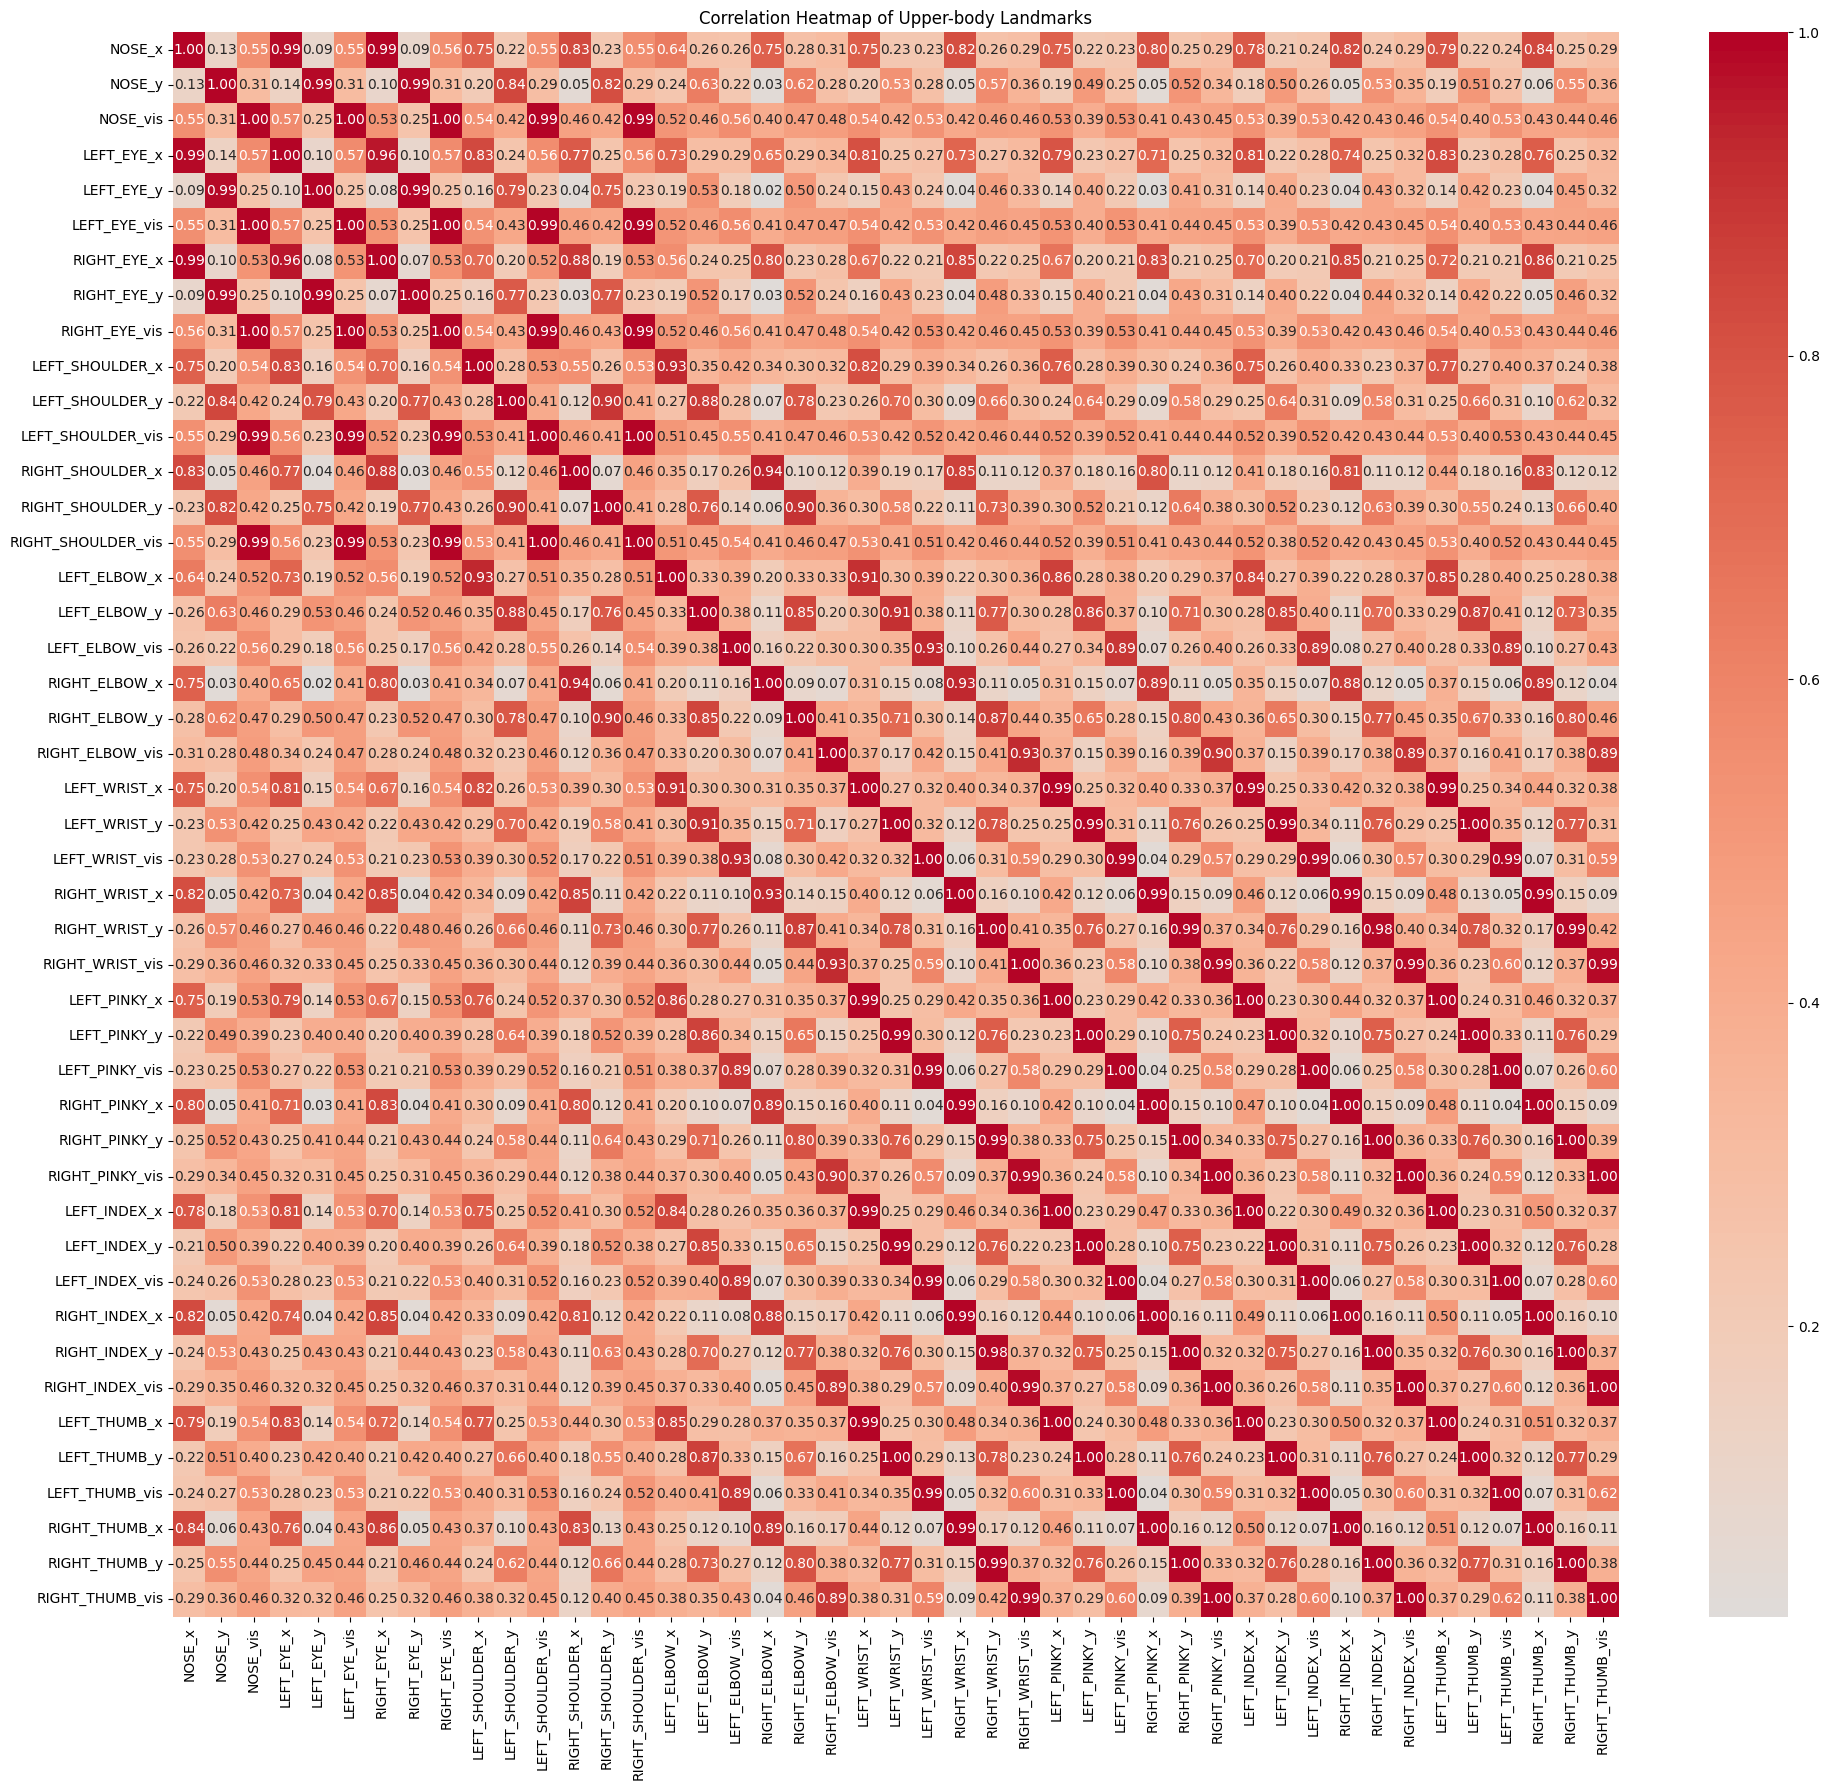

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming mp_pose is already imported from previous cells
import mediapipe as mp
mp_pose = mp.solutions.pose # Ensure mp_pose is defined

# Generate column names for df_features from MediaPipe landmarks
lm_names = [lm.name for lm in mp_pose.PoseLandmark]
all_feature_cols = []
for lm_name in lm_names:
    all_feature_cols.extend([f"{lm_name}_x", f"{lm_name}_y", f"{lm_name}_vis"])

# Calculate mean features for each sequence in X_seq
# X_seq shape is (N, num_frames, 99)
X_mean_features = X_seq.mean(axis=1) # shape (N, 99)

# Create df_features from the mean features
df_features = pd.DataFrame(X_mean_features, columns=all_feature_cols)

# --- Selecting only upper-body landmarks ---
upper_body_landmarks = [
    "NOSE", "LEFT_EYE", "RIGHT_EYE",
    "LEFT_SHOULDER", "RIGHT_SHOULDER",
    "LEFT_ELBOW", "RIGHT_ELBOW",
    "LEFT_WRIST", "RIGHT_WRIST",
    "LEFT_PINKY", "RIGHT_PINKY",
    "LEFT_INDEX", "RIGHT_INDEX",
    "LEFT_THUMB", "RIGHT_THUMB"
]

# Create a list of all column names relevant to upper body landmarks (x, y, vis for each)
upper_body_cols = []
for lm in upper_body_landmarks:
    upper_body_cols.extend([f"{lm}_x", f"{lm}_y", f"{lm}_vis"])

# Filter df_features to include only upper body landmark columns
df_upper = df_features[upper_body_cols]

# Compute correlation matrix
corr_upper = df_upper.corr()

# Plot heatmap
plt.figure(figsize=(20,18))
sns.heatmap(
    corr_upper,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Heatmap of Upper-body Landmarks")
plt.tight_layout()
plt.show()

In [ ]:
!pip install shap==0.42.1 --quiet


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(df_upper, y, test_size=0.2, random_state=42, stratify=y)

clf_upper = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
clf_upper.fit(X_tr, y_tr)

y_pred = clf_upper.predict(X_te)


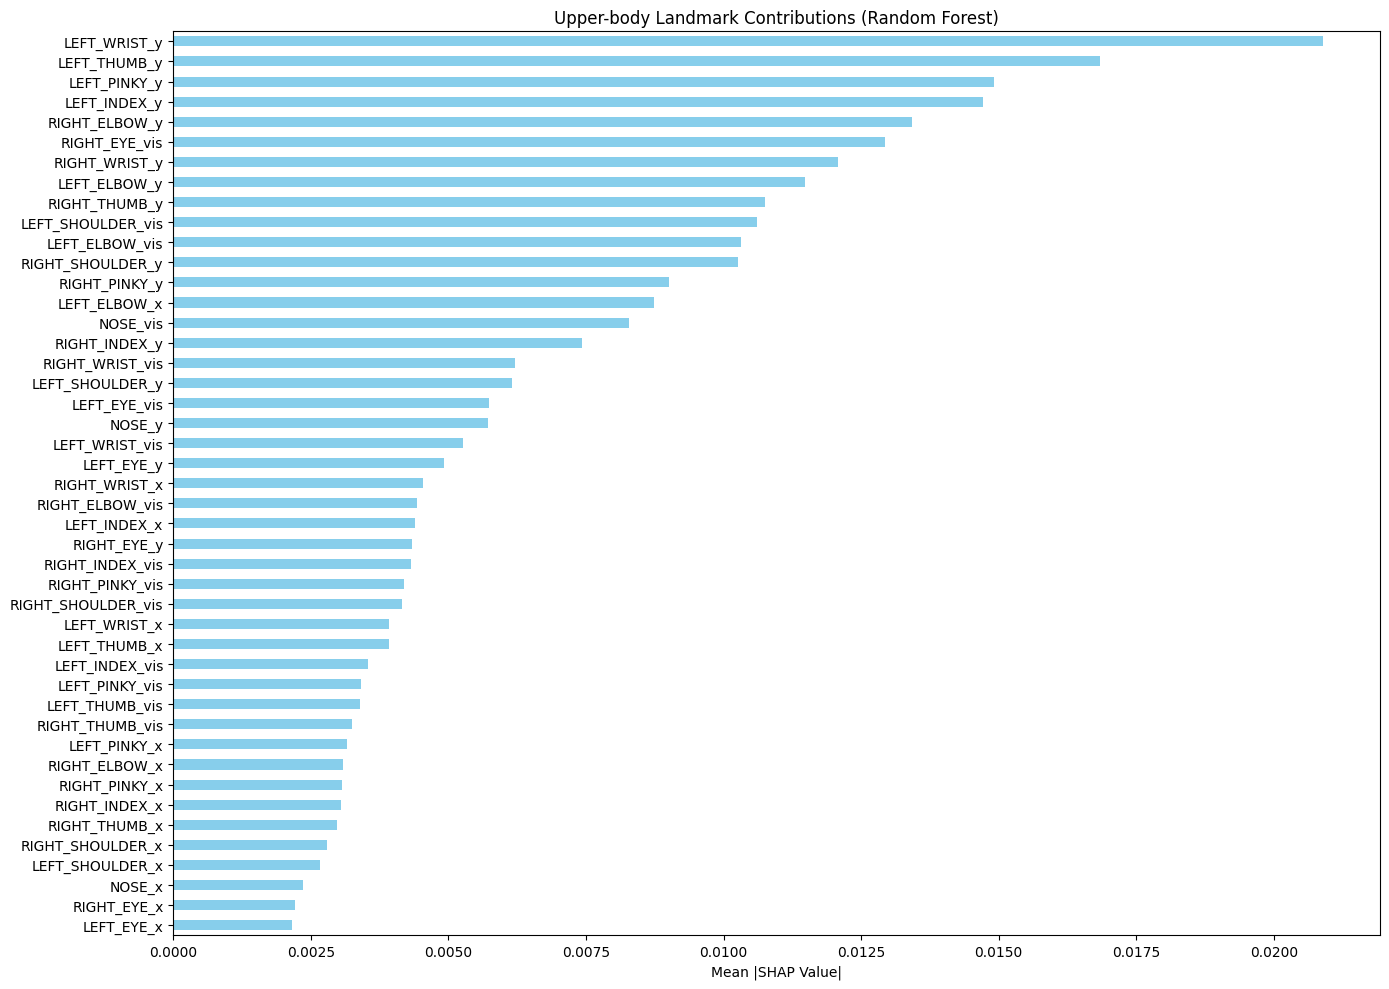

In [ ]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns

# Tree explainer
explainer = shap.TreeExplainer(clf_upper)
shap_values = explainer.shap_values(X_te)  # list of arrays per class

# Compute mean absolute SHAP per landmark across all classes
mean_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
shap_importance = pd.Series(mean_shap, index=df_upper.columns).sort_values(ascending=False)

# Plot top landmarks
plt.figure(figsize=(14,10))
shap_importance.plot(kind='barh', color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel("Mean |SHAP Value|")
plt.title("Upper-body Landmark Contributions (Random Forest)")
plt.tight_layout()
plt.show()


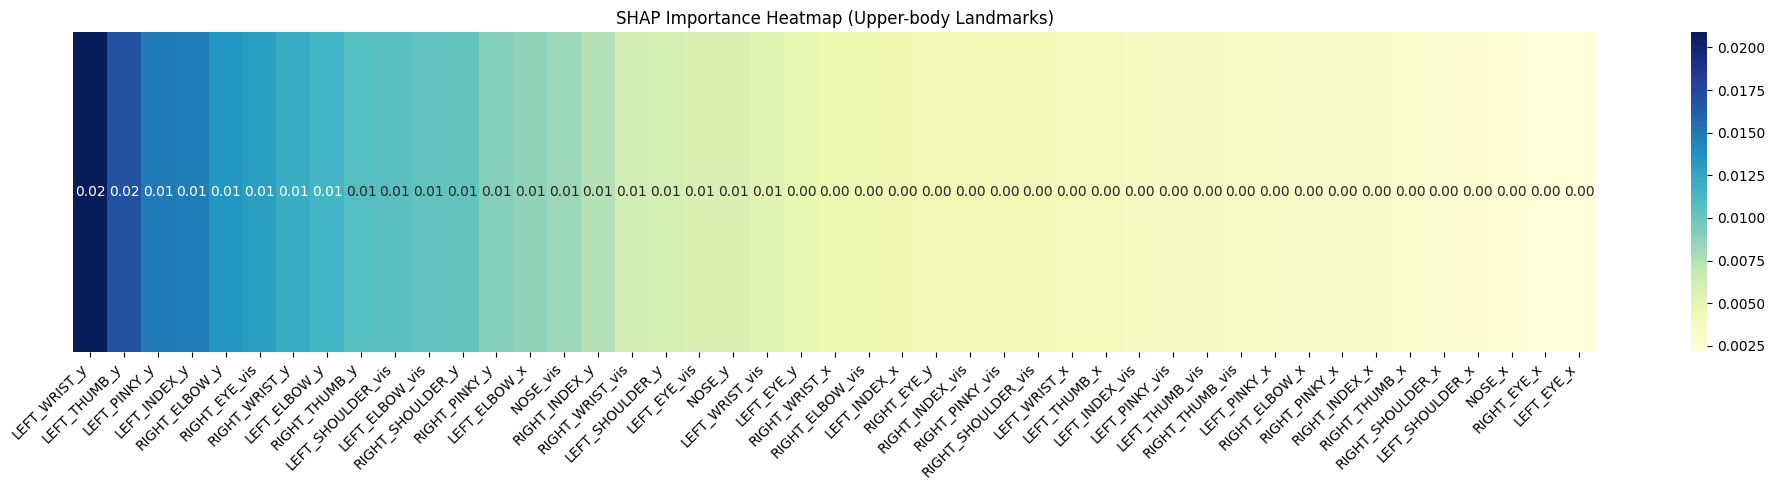

In [ ]:
plt.figure(figsize=(20,5))
sns.heatmap(shap_importance.values.reshape(1,-1), annot=True, fmt=".2f", cmap="YlGnBu", xticklabels=shap_importance.index)
plt.yticks([])
plt.xticks(rotation=45, ha="right")
plt.title("SHAP Importance Heatmap (Upper-body Landmarks)")
plt.tight_layout()
plt.show()


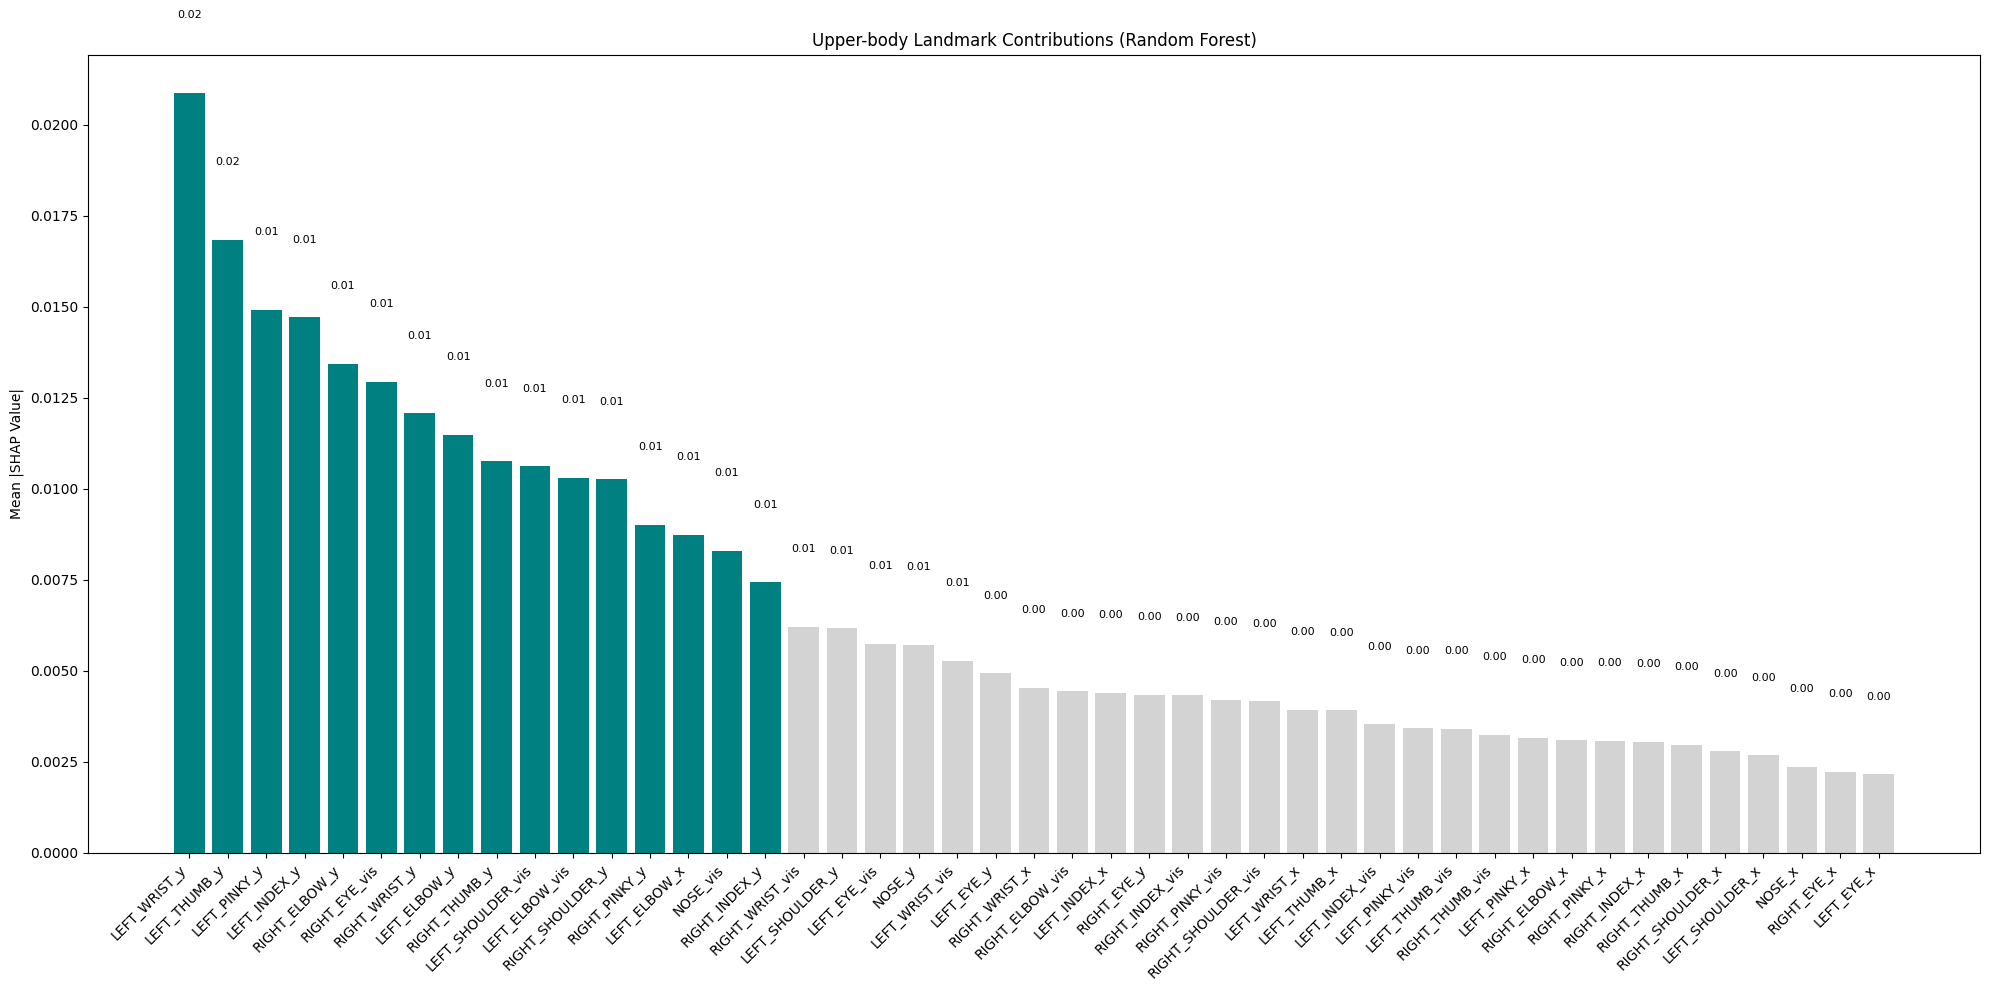

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Copy shap_importance from previous SHAP calculation
shap_df = shap_importance.copy()

# Define threshold to highlight top contributors
threshold = shap_df.max() * 0.3  # e.g., top ~30% of importance

colors = ['lightgray' if val < threshold else 'teal' for val in shap_df.values]

plt.figure(figsize=(20,10))
bars = plt.bar(shap_df.index, shap_df.values, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Mean |SHAP Value|")
plt.title("Upper-body Landmark Contributions (Random Forest)")

# Add numeric values above bars
for bar, val in zip(bars, shap_df.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.002, f"{val:.2f}",
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


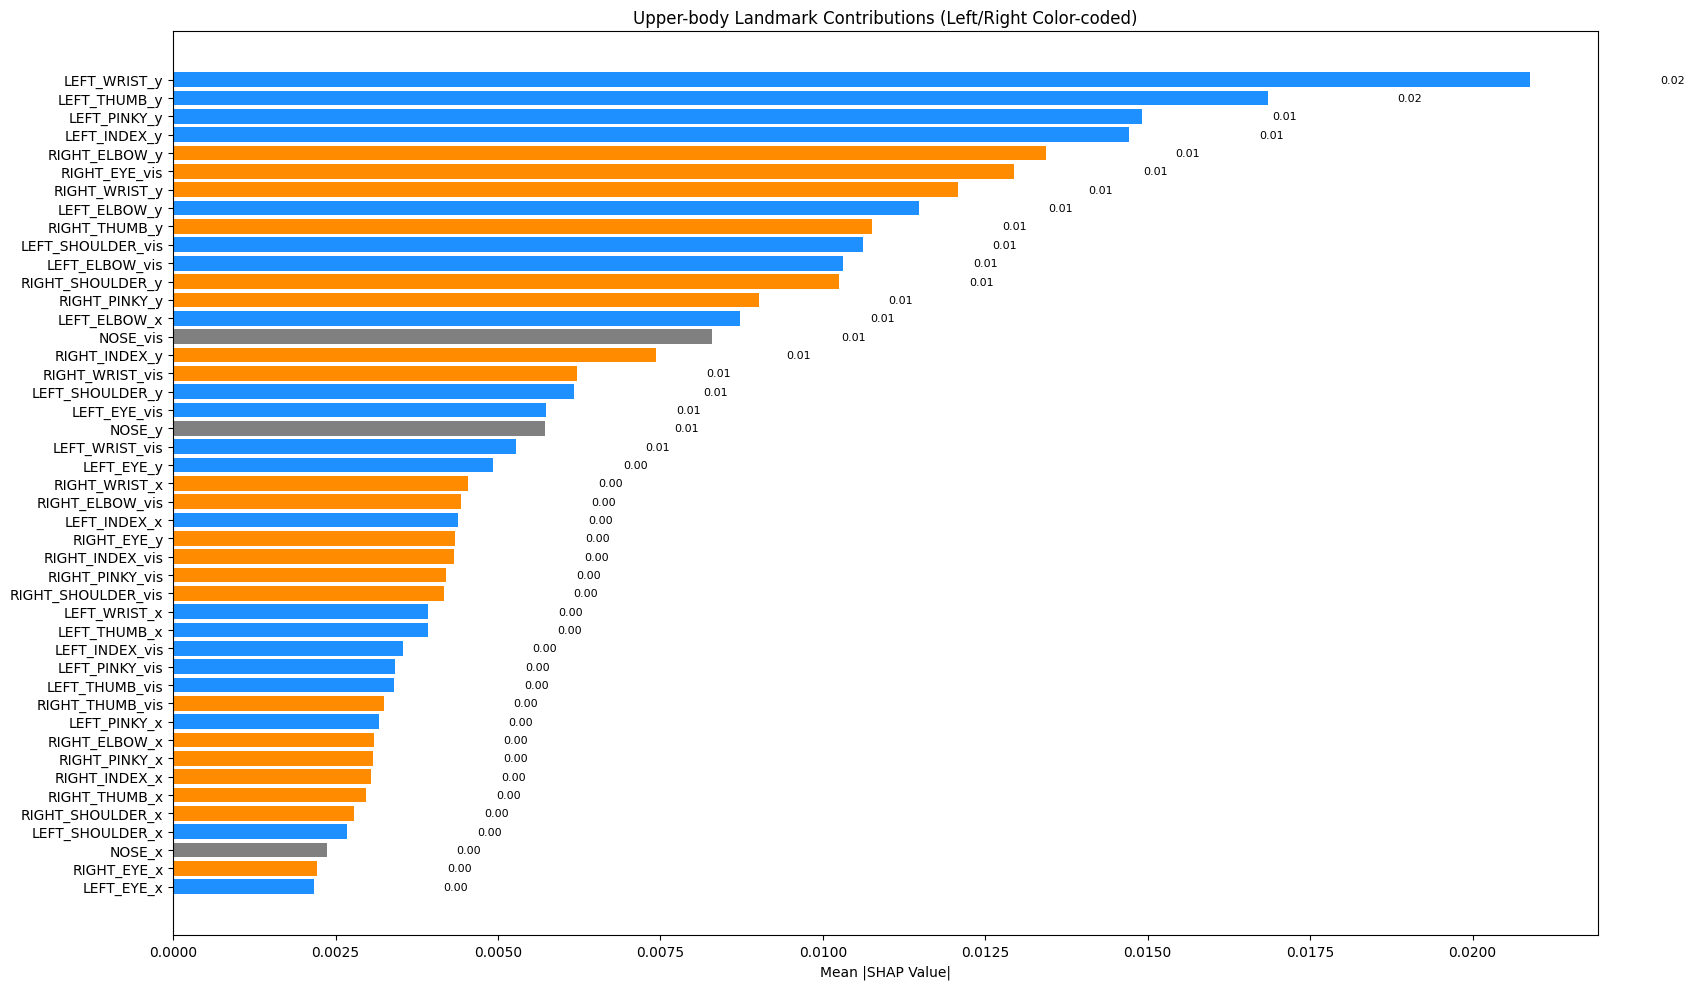

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Copy SHAP importance from previous step
shap_df = shap_importance.copy()

# Define left vs right landmarks
left_landmarks = [lm for lm in shap_df.index if lm.startswith("LEFT")]
right_landmarks = [lm for lm in shap_df.index if lm.startswith("RIGHT")]
neutral_landmarks = [lm for lm in shap_df.index if not lm.startswith(("LEFT","RIGHT"))]  # e.g., NOSE, EYE

# Assign colors
colors = []
for lm in shap_df.index:
    if lm in left_landmarks:
        colors.append("dodgerblue")
    elif lm in right_landmarks:
        colors.append("darkorange")
    else:
        colors.append("gray")  # neutral

# Horizontal bar plot
plt.figure(figsize=(17,10))
y_pos = range(len(shap_df))
plt.barh(y_pos, shap_df.values, color=colors)
plt.yticks(y_pos, shap_df.index)
plt.xlabel("Mean |SHAP Value|")
plt.title("Upper-body Landmark Contributions (Left/Right Color-coded)")

# Add numeric values to bars
for i, val in enumerate(shap_df.values):
    plt.text(val + 0.002, i, f"{val:.2f}", va='center', fontsize=8)

plt.gca().invert_yaxis()  # highest importance on top
plt.tight_layout()
plt.show()



===== Creating Final Model Comparison Chart =====

Final Accuracy Table:
                    Accuracy
HardVoting          0.862022
GradientBoosting    0.858689
RandomForest        0.852186
SoftVoting          0.802678
LogisticRegression  0.799344
BiLSTM              0.721311
KNN                 0.677650
SVM                 0.486776


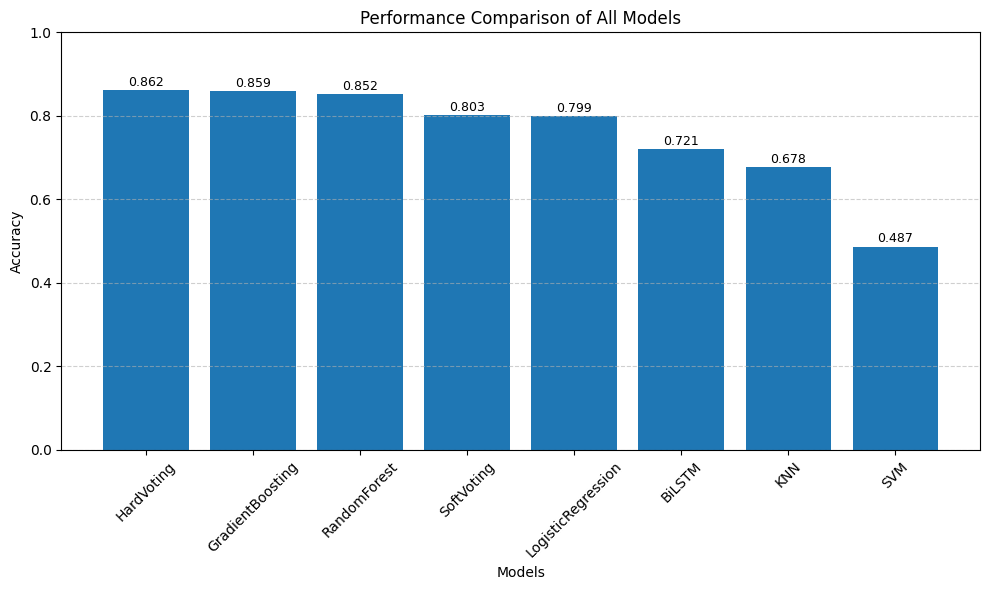

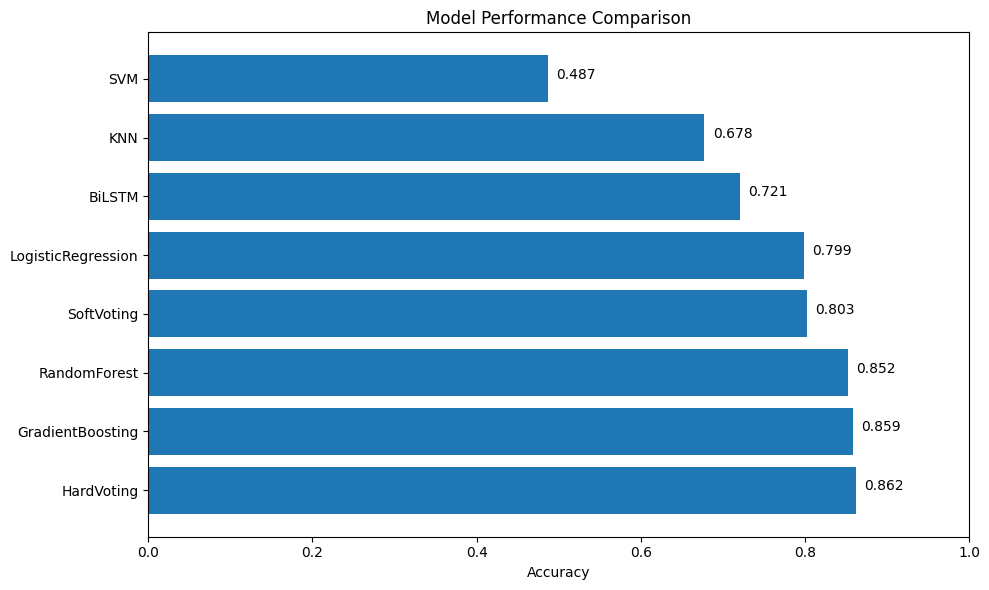

In [ ]:
# ============================================================
# FINAL MODEL COMPARISON CHART (ALL MODELS INCLUDING BiLSTM)
# ============================================================

print("\n===== Creating Final Model Comparison Chart =====")

# results dictionary already created earlier from classical models
# now we add LSTM

try:
    results["BiLSTM"] = lstm_accuracy
except:
    print("Warning: LSTM accuracy not found")

# Convert to dataframe
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
results_df = results_df.sort_values("Accuracy", ascending=False)

print("\nFinal Accuracy Table:")
print(results_df)

# -----------------------------
plt.figure(figsize=(10,6))

bars = plt.bar(results_df.index, results_df["Accuracy"])

plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.title("Performance Comparison of All Models")
plt.ylim(0,1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f"{height:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# -----------------------------
# HORIZONTAL VERSION
# -----------------------------
plt.figure(figsize=(10,6))

plt.barh(results_df.index, results_df["Accuracy"])
plt.xlabel("Accuracy")
plt.title("Model Performance Comparison")
plt.xlim(0,1)

for i, v in enumerate(results_df["Accuracy"]):
    plt.text(v + 0.01, i, f"{v:.3f}")

plt.tight_layout()
plt.show()



===== Generating Validation Curves for Best 2 Models =====
Best 2 models: ['GradientBoosting', 'RandomForest']

Processing GradientBoosting


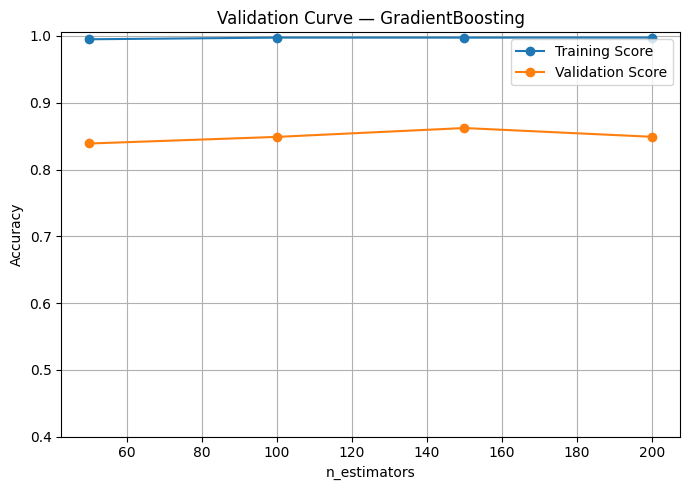


Processing RandomForest


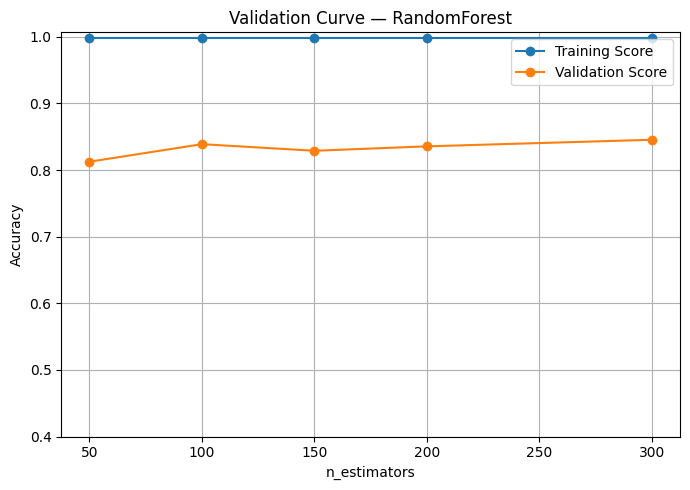

In [ ]:
# ============================================================
# VALIDATION CURVES FOR BEST 2 MODELS
# ============================================================

from sklearn.model_selection import validation_curve

print("\n===== Generating Validation Curves for Best 2 Models =====")

# Remove ensembles and LSTM from ranking (validation curve not meaningful for them)
classical_results = {k:v for k,v in results.items() if k in [
    "RandomForest", "SVM", "LogisticRegression", "KNN", "GradientBoosting"
]}

# Get top 2 models
best_two = sorted(classical_results, key=classical_results.get, reverse=True)[:2]
print("Best 2 models:", best_two)

# Parameter settings for each model
param_settings = {
    "RandomForest": ("n_estimators", [50, 100, 150, 200, 300]),
    "SVM": ("C", [0.01, 0.1, 1, 10, 100]),
    "LogisticRegression": ("C", [0.01, 0.1, 1, 10, 100]),
    "KNN": ("n_neighbors", [1, 3, 5, 7, 9, 11]),
    "GradientBoosting": ("n_estimators", [50, 100, 150, 200])
}

# Loop through best models
for model_name in best_two:

    print(f"\nProcessing {model_name}")

    model = models_dict[model_name]
    param_name, param_range = param_settings[model_name]

    train_scores, val_scores = validation_curve(
        model,
        X_feats,
        y,
        param_name=param_name,
        param_range=param_range,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    import numpy as np
    # Plot
    plt.figure(figsize=(7,5))
    plt.plot(param_range, train_mean, marker='o', label="Training Score")
    plt.plot(param_range, val_mean, marker='o', label="Validation Score")

    plt.xlabel(param_name)
    plt.ylabel("Accuracy")
    plt.title(f"Validation Curve — {model_name}")

    plt.yticks(np.arange(0.4, 1.01, 0.1))


    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



===== Generating Training & Validation Loss Curves (Best 2 Models) =====

Processing GradientBoosting


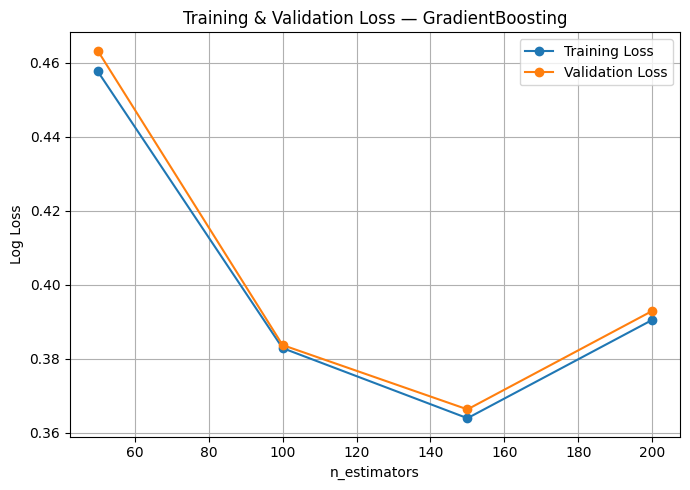


Processing RandomForest


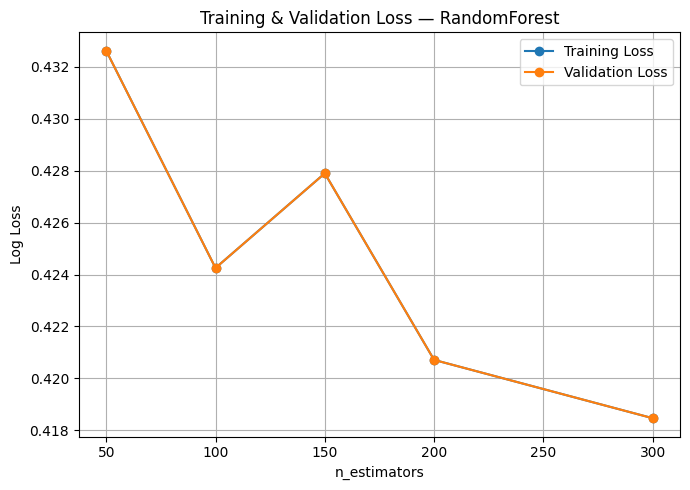

In [ ]:
from sklearn.model_selection import cross_val_score

print("\n===== Generating Training & Validation Loss Curves (Best 2 Models) =====")

# Loop through best models
for model_name in best_two:

    print(f"\nProcessing {model_name}")

    model = models_dict[model_name]
    param_name, param_range = param_settings[model_name]

    train_losses = []
    val_losses = []

    for param in param_range:
        # Set hyperparameter
        model.set_params(**{param_name: param})

        # Training loss: fit on full data then compute negative log loss
        model.fit(X_feats, y)
        train_loss = -cross_val_score(
            model, X_feats, y, cv=5, scoring="neg_log_loss"
        ).mean()
        val_loss = -cross_val_score(
            model, X_feats, y, cv=5, scoring="neg_log_loss"
        ).mean()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    # Plot Loss Curves
    plt.figure(figsize=(7,5))
    plt.plot(param_range, train_losses, marker='o', label="Training Loss")
    plt.plot(param_range, val_losses, marker='o', label="Validation Loss")
    plt.xlabel(param_name)
    plt.ylabel("Log Loss")
    plt.title(f"Training & Validation Loss — {model_name}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
import joblib
from sklearn.ensemble import GradientBoostingClassifier

print("\n===== Training FINAL GradientBoosting model =====")

final_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    subsample=0.8,
    random_state=42
)

# train only on training data
final_gb.fit(X_tr, y_tr)

print("Final GradientBoosting trained!")




===== Training FINAL GradientBoosting model =====
Final GradientBoosting trained!


In [ ]:
y_pred_gb = final_gb.predict(X_te)
print("GradientBoosting Test Accuracy:", accuracy_score(y_te, y_pred_gb))


GradientBoosting Test Accuracy: 0.7704918032786885


In [ ]:
joblib.dump(final_gb, "gradient_boosting_model.pkl")

print("Model saved → gradient_boosting_model.pkl")


Model saved → gradient_boosting_model.pkl


In [ ]:
model_bundle = {
    "model": final_gb,
    "labels": labels,
    "feature_dim": X_feats.shape[1]
}

joblib.dump(model_bundle, "autism_model_bundle.pkl")


['autism_model_bundle.pkl']

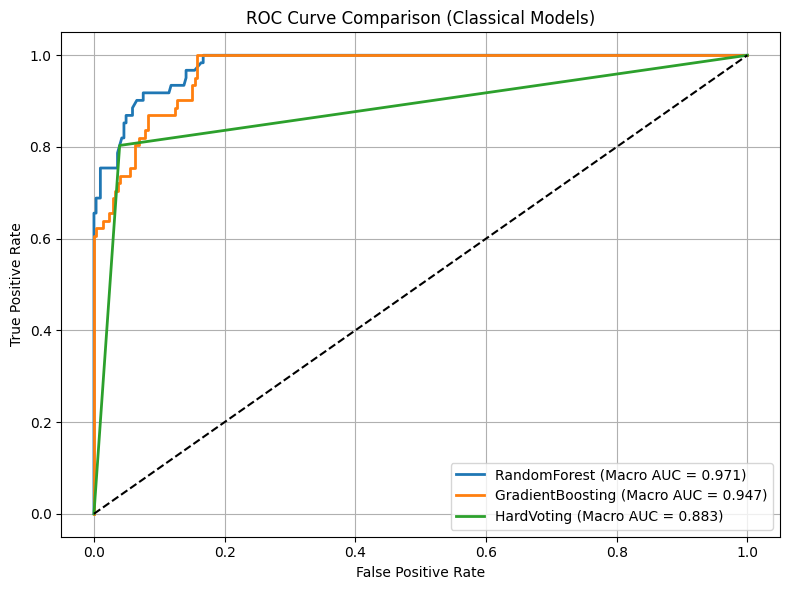

In [ ]:
# ============================================================
# ROC–AUC CURVES FOR BEST CLASSICAL MODELS
# RandomForest, GradientBoosting, HardVoting
# ============================================================

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Ensure models are fitted
clf.fit(X_tr, y_tr)
final_gb.fit(X_tr, y_tr)
hard_vote.fit(X_tr, y_tr)

# Binarize labels for multi-class ROC
y_test_bin = label_binarize(y_te, classes=range(len(labels)))

models_for_roc = {
    "RandomForest": clf,
    "GradientBoosting": final_gb
}

plt.figure(figsize=(8,6))

for name, model in models_for_roc.items():

    # Get probabilities
    y_prob = model.predict_proba(X_te)

    auc_scores = []

    for i in range(len(labels)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        auc_scores.append(roc_auc)

    macro_auc = np.mean(auc_scores)

    # Plot macro ROC
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
    plt.plot(fpr, tpr, lw=2, label=f"{name} (Macro AUC = {macro_auc:.3f})")


# ------------------------------------------------------------
# HARD VOTING (no predict_proba)
# approximate probability using decision function if available
# ------------------------------------------------------------

try:
    if hasattr(hard_vote, "predict_proba"):
        y_prob = hard_vote.predict_proba(X_te)
    else:
        # fallback
        y_pred = hard_vote.predict(X_te)
        y_prob = label_binarize(y_pred, classes=range(len(labels)))

    auc_scores = []

    for i in range(len(labels)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        auc_scores.append(roc_auc)

    macro_auc = np.mean(auc_scores)

    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
    plt.plot(fpr, tpr, lw=2, label=f"HardVoting (Macro AUC = {macro_auc:.3f})")

except Exception as e:
    print("HardVoting ROC skipped:", e)


# Random baseline
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Classical Models)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()